In [1]:
# ID3
data = {
    'Outlook':['Sunny','Sunny','Overcast','Rainy','Rainy'],
    'Humidity': ['High', 'High', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Strong'],
    'Play':['No','No','Yes','Yes','No']
}

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
import pandas as pd


In [4]:
df = pd.DataFrame(data)

In [ ]:
df.head()


,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rainy,Normal,Weak,Yes
4,Rainy,Normal,Strong,No


In [15]:
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

y_val = ["No","Yes"]

In [16]:
df.head()

,Outlook,Humidity,Wind,Play
0,2,0,1,0
1,2,0,0,0
2,0,0,1,1
3,1,1,1,1
4,1,1,0,0


In [10]:
X = df.drop(columns=['Play'])
y= df.Play

In [13]:
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [18]:
new_data=[[2,0,1]]
y_val[model.predict(new_data)[0]]

/Users/prince-khatri/Desktop/Sem-6/ml-lab/env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


'No'

In [21]:
rules = export_text(
    model,
    feature_names=X.columns.tolist(),
)
print(rules)

|--- Outlook <= 1.50
|   |--- Wind <= 0.50
|   |   |--- class: 0
|   |--- Wind >  0.50
|   |   |--- class: 1
|--- Outlook >  1.50
|   |--- class: 0



[Text(0.6, 0.8333333333333334, 'Outlook <= 1.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 2]\nclass = No'),
 Text(0.4, 0.5, 'Wind <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]\nclass = Yes'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No'),
 Text(0.6, 0.16666666666666666, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Yes'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = No'),
 Text(0.7, 0.6666666666666667, '  False')]

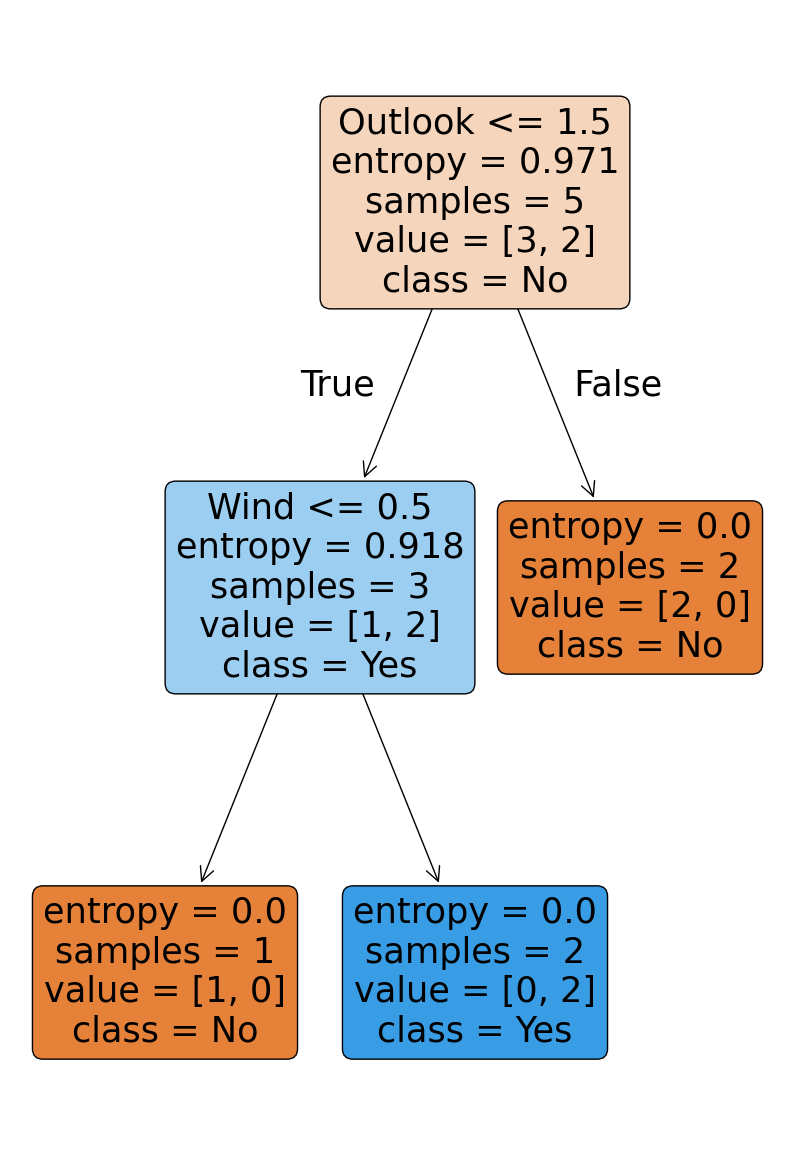

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,15))
plot_tree(model, feature_names=X.columns.tolist(), class_names=y_val, filled=True, rounded=True)

In [ ]:
# Write a program to demonstrate the working of the decision tree based ID3 algorithm Use an appropriate data set for 
# building the decision tree and apply this knowledge to classify a new sample. Interpret the results.
#  Write the inference/analysis of each output

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
import pandas as pd
import matplotlib.pyplot as plt
# ID3
data = {
    'Outlook':['Sunny','Sunny','Overcast','Rainy','Rainy'],
    'Humidity': ['High', 'High', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Strong'],
    'Play':['No','No','Yes','Yes','No']
}

df = pd.DataFrame(data)
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])
X = df.drop(columns=['Play'])
y = df['Play']



In [14]:

model = DecisionTreeClassifier(criterion='entropy')
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

Accuracy:  1.0


[Text(0.6, 0.8333333333333334, 'x[0] <= 1.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 2]\nclass = No'),
 Text(0.4, 0.5, 'x[2] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]\nclass = Yes'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No'),
 Text(0.6, 0.16666666666666666, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Yes'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = No'),
 Text(0.7, 0.6666666666666667, '  False')]

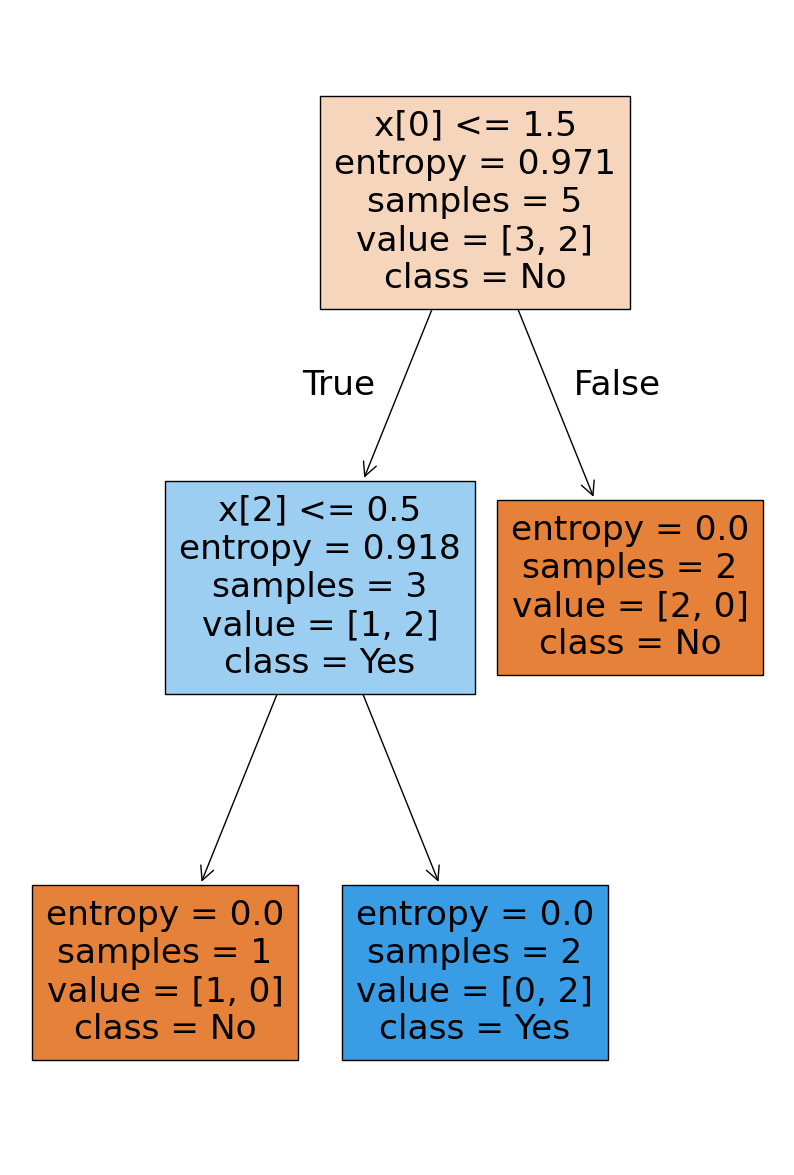

In [17]:

model.fit(X,y)

y_pred = model.predict(X)

print("Accuracy: ", accuracy_score(y, y_pred))
plt.figure(figsize=(10,15))
plot_tree(model, filled=True, class_names=["No","Yes"])

In [8]:
help(plot_tree)

Help on function plot_tree in module sklearn.tree._export:

plot_tree(
    decision_tree,
    *,
    max_depth=None,
    feature_names=None,
    class_names=None,
    label='all',
    filled=False,
    impurity=True,
    node_ids=False,
    proportion=False,
    rounded=False,
    precision=3,
    ax=None,
    fontsize=None
)
    Plot a decision tree.

    The sample counts that are shown are weighted with any sample_weights that
    might be present.

    The visualization is fit automatically to the size of the axis.
    Use the ``figsize`` or ``dpi`` arguments of ``plt.figure``  to control
    the size of the rendering.

    Read more in the :ref:`User Guide <tree>`.

    .. versionadded:: 0.21

    Parameters
    ----------
    decision_tree : decision tree regressor or classifier
        The decision tree to be plotted.

    max_depth : int, default=None
        The maximum depth of the representation. If None, the tree is fully
        generated.

    feature_names : array-like o